In [1]:
import jax.numpy as jnp
from jax import config
config.update("jax_enable_x64", True)
import numpy as np
import matplotlib.pyplot as plt
from peps import *

In [4]:
J = 1
D = 6
step=0.05
tlist = np.arange(0.1, 4.5, step)

f = []
for t in tlist:
    beta = 1 / t
    ta = jnp.zeros((2, 2, 2), dtype=jnp.float64)
    tb = jnp.array((2, 2, 2), dtype=jnp.float64)

    ta = ta.at[([1, 0, 1, 0], [1, 0, 0, 1], [1, 1, 0, 0])].set([
        np.exp((3/2)*beta*J), np.exp(-(1/2)*beta*J), np.exp(-(1/2)*beta*J), np.exp(-(1/2)*beta*J)
    ])
    tb = ta.copy()

    f.append(TensorRG(ta, tb).start(D, t, ite=5))

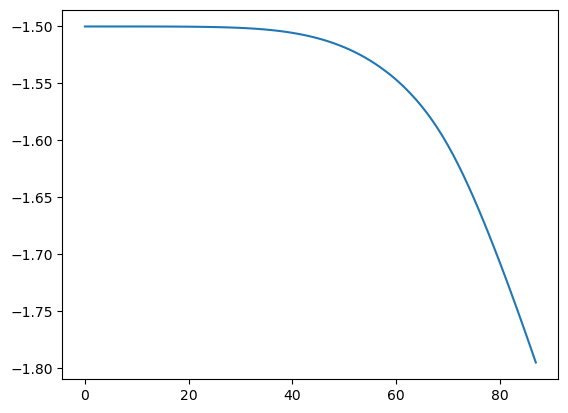

In [5]:
plt.plot(f)

In [15]:
peps = PEPS(3, 10)
J = 1
ite = 10
energy = []
tau = [0.01] * 100 + [0.01] * 100 + [0.001] * 100
for i in range(300):
    peps.single_update(tau[i], J)
    e = peps.cal_energy(J, ite)
    E = np.sum(e)
    energy.append(1.5 * E)
    print(1.5 * E.real)

-0.12903397313468656
-0.1314208026137187
-0.13768930703514304
-0.14104182545604205
-0.15005453562283416
-0.15375683641483506
-0.15904771601129175
-0.16522050692554127
-0.1764940598793861
-0.18423389396626627
-0.18998905414473063
-0.19824366975758498
-0.20560045945448063
-0.2124167123086959
-0.21920444305617975
-0.216942607999338
-0.22316667113727248
-0.23951227760072596
-0.23476968592247935
-0.2417428657697644
-0.24835360221857838
-0.25039750328446486
-0.2554274106915101
-0.2717350670379923
-0.2771601287163532
-0.2726199225955336
-0.28987964966012497
-0.28180019138276985
-0.2867889126564009
-0.2938238535806471
-0.3119155007219811
-0.31682306973388974
-0.3195201902563723
-0.32699595180791596
-0.32975738161946705
-0.3210690009055185
-0.3439091400668379
-0.34748573477703476
-0.35365800247550017
-0.3624193070045048
-0.3543243948436996
-0.3733381633273696
-0.36691720655127613
-0.3854428229739143
-0.3772174587058942
-0.3840049579753374
-0.389836387967771
-0.3956548330050902
-0.40198922408887

KeyboardInterrupt: 

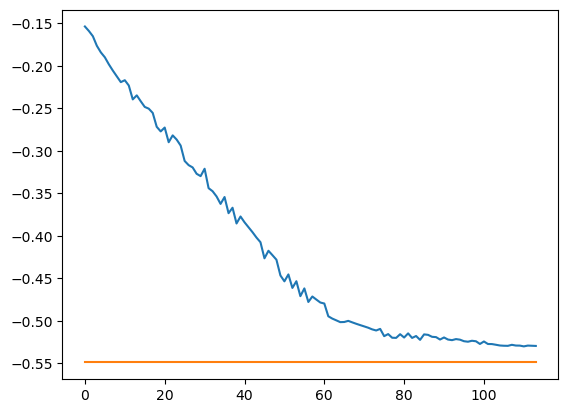

In [16]:
plt.plot(np.array(energy).real[5:])
plt.plot([-0.5489] * len(np.array(energy).real[5:]))